# 04 - Model Improvement

**Masalah notebook 03:**
- HOLD 84% → model bias ke HOLD
- BUY/SELL F1 hanya 7-14%
- Win rate 49.5% = coin flip

**Strategi perbaikan:**
1. Binary classifier: hanya BUY vs SELL (buang HOLD dari training)
2. Filter sinyal: hanya masuk kalau ATR cukup besar (market bergerak)
3. Perbaiki labeling: lookahead lebih ketat, minimal 3 pips movement
4. Threshold tuning: hanya execute kalau confidence model > 60%

## 1. Import & Load

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, roc_auc_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import joblib

os.makedirs('models', exist_ok=True)
sns.set_theme(style='darkgrid')

df_raw = pd.read_csv('EURUSD_M15_cleaned.csv', index_col='datetime', parse_dates=True)
df_raw = df_raw.sort_index()

print(f'Data loaded: {df_raw.shape}')
print(df_raw['signal'].value_counts())

Data loaded: (100248, 28)
signal
HOLD    84447
BUY      7967
SELL     7834
Name: count, dtype: int64


## 2. Perbaiki Labeling — Filter ATR & Minimum Movement

In [2]:
df = df_raw.copy()

# Re-label dengan kriteria lebih ketat
# Parameter
SL_MULT   = 1.0
TP_MULT   = 1.5     # RR 1:1.5 (lebih mudah tercapai dari 1:2)
LOOKAHEAD = 3       # 3 candle ke depan = 45 menit
MIN_ATR_PIPS = 8    # Hanya label jika ATR > 8 pips (market cukup volatile)

close_arr = df['close'].values
atr_arr   = df['atr_14'].values

signals, sl_vals, tp_vals = [], [], []

for i in range(len(df)):
    if i + LOOKAHEAD >= len(df):
        signals.append('HOLD'); sl_vals.append(np.nan); tp_vals.append(np.nan)
        continue

    entry = close_arr[i]
    atr   = atr_arr[i]

    # Filter: skip kalau ATR terlalu kecil (market sideways/flat)
    if np.isnan(atr) or (atr / 0.0001) < MIN_ATR_PIPS:
        signals.append('HOLD'); sl_vals.append(np.nan); tp_vals.append(np.nan)
        continue

    future = close_arr[i+1 : i+1+LOOKAHEAD]
    max_f  = np.max(future)
    min_f  = np.min(future)

    sl_buy  = entry - (SL_MULT * atr)
    tp_buy  = entry + (TP_MULT * atr)
    sl_sell = entry + (SL_MULT * atr)
    tp_sell = entry - (TP_MULT * atr)

    hit_tp_buy  = max_f >= tp_buy  and min_f > sl_buy
    hit_tp_sell = min_f <= tp_sell and max_f < sl_sell

    if hit_tp_buy:
        signals.append('BUY');  sl_vals.append(round(sl_buy, 5));  tp_vals.append(round(tp_buy, 5))
    elif hit_tp_sell:
        signals.append('SELL'); sl_vals.append(round(sl_sell, 5)); tp_vals.append(round(tp_sell, 5))
    else:
        signals.append('HOLD'); sl_vals.append(np.nan); tp_vals.append(np.nan)

df['signal'] = signals
df['sl']     = sl_vals
df['tp']     = tp_vals

print('Distribusi signal baru (lebih ketat):')
print(df['signal'].value_counts())
print()
pct = df['signal'].value_counts(normalize=True).mul(100).round(1)
print(pct)

Distribusi signal baru (lebih ketat):
signal
HOLD    94061
BUY      3130
SELL     3057
Name: count, dtype: int64

signal
HOLD    93.8
BUY      3.1
SELL     3.0
Name: proportion, dtype: float64


## 3. Feature Engineering Tambahan

In [3]:
# Fitur relatif (normalisasi terhadap ATR agar scale-independent)
df['body_atr']         = df['body']         / df['atr_14']
df['upper_shadow_atr'] = df['upper_shadow'] / df['atr_14']
df['lower_shadow_atr'] = df['lower_shadow'] / df['atr_14']

# EMA cross signals
df['ema9_vs_21']     = df['ema_9']  - df['ema_21']
df['ema50_vs_200']   = df['ema_50'] - df['ema_200']
df['close_vs_bb']    = (df['close'] - df['bb_mid']) / (df['bb_upper'] - df['bb_lower'] + 1e-10)
df['close_vs_ema21'] = df['close']  - df['ema_21']

# RSI normalized
df['rsi_centered'] = df['rsi_14'] - 50  # positif = bullish, negatif = bearish

# MACD normalized
df['macd_norm'] = df['macd_hist'] / (df['atr_14'] + 1e-10)

# Trend strength
df['trend_strength'] = (df['ema_50'] - df['ema_200']) / df['atr_14']

FEATURES = [
    'rsi_centered', 'macd_norm', 'macd_hist',
    'ema9_vs_21', 'ema50_vs_200', 'trend_strength',
    'close_vs_bb', 'close_vs_ema21',
    'body_atr', 'upper_shadow_atr', 'lower_shadow_atr', 'candle_dir',
    'return', 'return_3', 'return_5',
    'atr_14', 'tick_vol', 'spread'
]

df_clean = df[FEATURES + ['signal', 'close']].dropna().copy()
print(f'Total fitur: {len(FEATURES)}')
print(f'Total baris: {len(df_clean):,}')

Total fitur: 18
Total baris: 100,248


## 4. Strategi A — Binary: BUY vs SELL (tanpa HOLD)

In [4]:
# Hanya ambil baris yang BUY atau SELL
df_binary = df_clean[df_clean['signal'].isin(['BUY', 'SELL'])].copy()

print(f'Total BUY+SELL: {len(df_binary):,}')
print(df_binary['signal'].value_counts())

# Split time series
split_idx  = int(len(df_binary) * 0.80)
train_b    = df_binary.iloc[:split_idx]
test_b     = df_binary.iloc[split_idx:]

X_train_b  = train_b[FEATURES]
y_train_b  = train_b['signal']
X_test_b   = test_b[FEATURES]
y_test_b   = test_b['signal']

print(f'\nTrain: {len(train_b):,}  ({train_b.index.min().date()} -> {train_b.index.max().date()})')
print(f'Test : {len(test_b):,}  ({test_b.index.min().date()} -> {test_b.index.max().date()})')

Total BUY+SELL: 6,187
signal
BUY     3130
SELL    3057
Name: count, dtype: int64

Train: 4,949  (2021-12-16 -> 2025-04-14)
Test : 1,238  (2025-04-14 -> 2026-03-25)


In [5]:
# Train XGBoost binary
le_b = LabelEncoder()
y_train_enc = le_b.fit_transform(y_train_b)  # BUY=0, SELL=1
y_test_enc  = le_b.transform(y_test_b)

xgb_binary = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=1.0,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_binary.fit(
    X_train_b, y_train_enc,
    eval_set=[(X_test_b, y_test_enc)],
    verbose=False
)

y_pred_enc  = xgb_binary.predict(X_test_b)
y_pred_b    = le_b.inverse_transform(y_pred_enc)
y_proba_b   = xgb_binary.predict_proba(X_test_b)

print('=== Binary XGBoost (BUY vs SELL) ===')
print(classification_report(y_test_b, y_pred_b, digits=4))
f1_binary = f1_score(y_test_b, y_pred_b, average='macro')
print(f'Macro F1: {f1_binary:.4f}')

=== Binary XGBoost (BUY vs SELL) ===
              precision    recall  f1-score   support

         BUY     0.5078    0.5117    0.5097       639
        SELL     0.4747    0.4708    0.4728       599

    accuracy                         0.4919      1238
   macro avg     0.4913    0.4913    0.4913      1238
weighted avg     0.4918    0.4919    0.4918      1238

Macro F1: 0.4913


## 5. Threshold Confidence — Hanya Execute jika Model Yakin

In [6]:
# Confidence = max probability dari prediksi
confidence   = y_proba_b.max(axis=1)
thresholds   = [0.50, 0.55, 0.60, 0.65, 0.70]

print(f'{'Threshold':>12} | {'Trades':>8} | {'Coverage':>10} | {'F1':>8}')
print('-' * 48)

best_f1, best_thresh = 0, 0.50
for thresh in thresholds:
    mask     = confidence >= thresh
    y_t_mask = y_test_b.values[mask]
    y_p_mask = y_pred_b[mask]
    n_trades = mask.sum()
    coverage = n_trades / len(y_test_b) * 100
    if n_trades > 10:
        f1 = f1_score(y_t_mask, y_p_mask, average='macro')
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
        print(f'{thresh:>12.2f} | {n_trades:>8,} | {coverage:>9.1f}% | {f1:>8.4f}')

print(f'\nBest threshold: {best_thresh} (F1={best_f1:.4f})')

   Threshold |   Trades |   Coverage |       F1
------------------------------------------------
        0.50 |    1,238 |     100.0% |   0.4913
        0.55 |      841 |      67.9% |   0.5033
        0.60 |      540 |      43.6% |   0.4875
        0.65 |      277 |      22.4% |   0.4875
        0.70 |      117 |       9.5% |   0.4936

Best threshold: 0.55 (F1=0.5033)


## 6. Backtest dengan Threshold Optimal

Threshold      : 0.55
Total trade    : 841
Win            : 430
Win rate       : 51.1%
Total return   : nan%


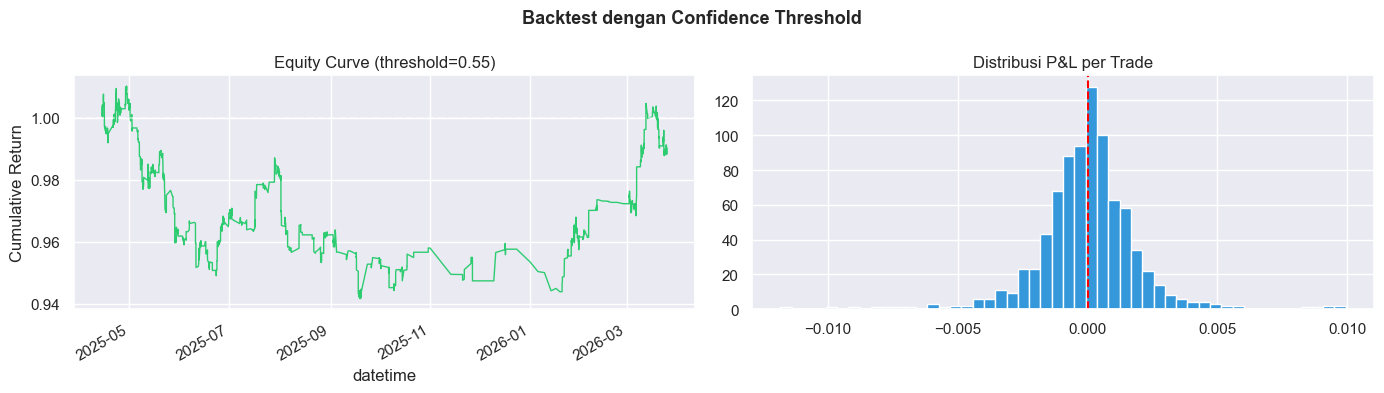

In [7]:
# Backtest hanya pada candle dengan confidence >= best_thresh
bt = test_b.copy()
bt['pred']       = y_pred_b
bt['confidence'] = confidence
bt['next_return'] = bt['close'].pct_change().shift(-1)

# Hanya execute trade jika confidence cukup
bt['execute'] = bt['confidence'] >= best_thresh

bt['trade_pnl'] = np.where(
    bt['execute'] & (bt['pred'] == 'BUY'),   bt['next_return'],
    np.where(
    bt['execute'] & (bt['pred'] == 'SELL'), -bt['next_return'], 0)
)

trades       = bt[bt['execute']].copy()
total_trades = len(trades)
win_trades   = (trades['trade_pnl'] > 0).sum()
win_rate     = win_trades / total_trades * 100 if total_trades > 0 else 0
cumulative   = (1 + bt['trade_pnl']).cumprod()

print(f'Threshold      : {best_thresh}')
print(f'Total trade    : {total_trades:,}')
print(f'Win            : {win_trades:,}')
print(f'Win rate       : {win_rate:.1f}%')
print(f'Total return   : {(cumulative.iloc[-1] - 1) * 100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cumulative.plot(ax=axes[0], color='#2ecc71', linewidth=1)
axes[0].axhline(1.0, color='white', linestyle='--', alpha=0.5)
axes[0].set_title(f'Equity Curve (threshold={best_thresh})')
axes[0].set_ylabel('Cumulative Return')
trades['trade_pnl'].hist(bins=50, ax=axes[1], color='#3498db', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribusi P&L per Trade')
plt.suptitle('Backtest dengan Confidence Threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Confusion Matrix & Feature Importance

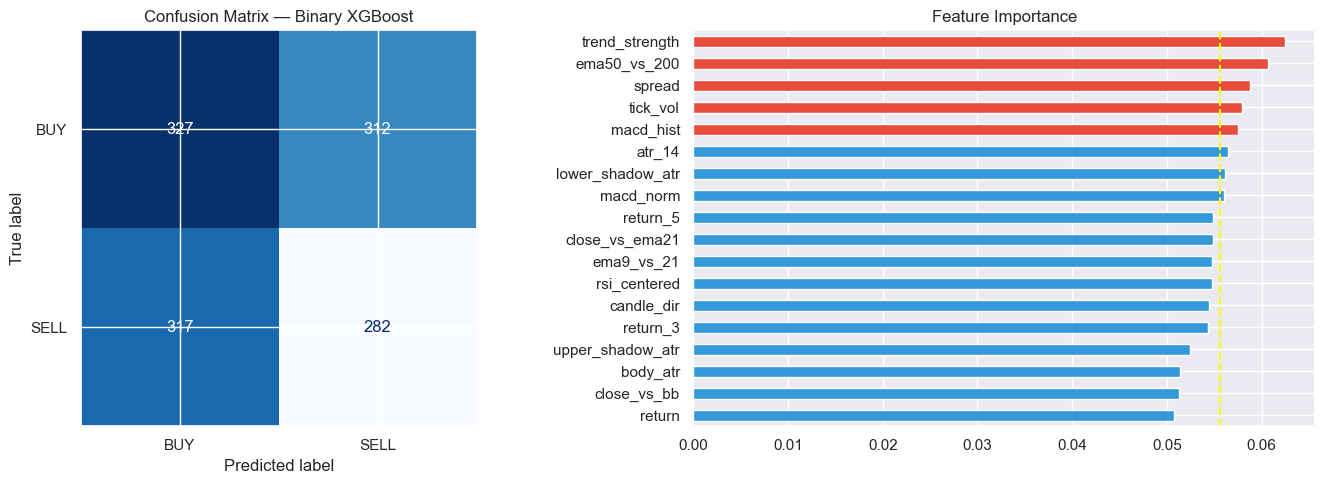

Top 10 fitur:
  trend_strength           : 0.0625
  ema50_vs_200             : 0.0607
  spread                   : 0.0588
  tick_vol                 : 0.0579
  macd_hist                : 0.0575
  atr_14                   : 0.0565
  lower_shadow_atr         : 0.0561
  macd_norm                : 0.0560
  return_5                 : 0.0549
  close_vs_ema21           : 0.0549


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test_b, y_pred_b, labels=['BUY','SELL'])
ConfusionMatrixDisplay(cm, display_labels=['BUY','SELL']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Binary XGBoost')

# Feature importance
fi = pd.Series(xgb_binary.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors = ['#e74c3c' if v >= fi.quantile(0.75) else '#3498db' for v in fi.values]
fi.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Feature Importance')
axes[1].axvline(fi.mean(), color='yellow', linestyle='--')

plt.tight_layout()
plt.show()

print('Top 10 fitur:')
for f, v in fi.sort_values(ascending=False).head(10).items():
    print(f'  {f:25s}: {v:.4f}')

## 8. Simpan Model Improved

In [ ]:
joblib.dump(xgb_binary,   'models/signal_model_v2.pkl')
joblib.dump(le_b,         'models/label_encoder_v2.pkl')
joblib.dump(FEATURES,     'models/feature_list_v2.pkl')
joblib.dump(best_thresh,  'models/confidence_threshold.pkl')

print('Model v2 disimpan:')
print('  models/signal_model_v2.pkl')
print('  models/label_encoder_v2.pkl')
print('  models/feature_list_v2.pkl')
print(f'  models/confidence_threshold.pkl  (threshold={best_thresh})')
print(f'\nBinary F1 Score : {f1_binary:.4f}')
print(f'Win rate        : {win_rate:.1f}%')
print(f'Total return    : {(cumulative.iloc[-1] - 1) * 100:.2f}%')
print('\nModel v2 siap diintegrasikan ke trade_signal!')

Model v2 disimpan:
  models/signal_model_v2.pkl
  models/label_encoder_v2.pkl
  models/feature_list_v2.pkl
  models/confidence_threshold.pkl  (threshold=0.55)

Binary F1 Score : 0.4913
Win rate        : 51.1%
Total return    : nan%

Model v2 siap diintegrasikan ke trade_signal!
